# Perfil de jugador: arquetipos por estilo de juego

El script de producción arma el arquetipo con `KMeans(k=5)` sobre 8 variables ya escaladas -- una decisión rápida que se tomó al armar la app, sin comparar alternativas. Acá probamos si se puede mejorar antes de tocar el script real:

1. ¿`k=5` es realmente un buen número, o fue solo lo más práctico en el momento?
2. Las 3 variables ofensivas están escaladas por posición (bueno para el modelo de valor) -- pero para encontrar *estilos de juego* eso puede ser contraproducente: un central con pocos goles "pero muchos para un central" terminaría pareciéndose a un delantero goleador. Comparamos contra escala global.
3. ¿KMeans es el algoritmo correcto, o conviene comparar contra Gaussian Mixture / Agglomerative?

Este notebook es solo terreno de pruebas -- no toca `scripts/build_model_artifacts.py`. Si algo mejora de verdad, se traslada después.

In [1]:
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA

pd.set_option('display.max_columns', None)
RANDOM_STATE = 42

## 1. Carga de datos

Unimos `fbref_tm_features.parquet` (las columnas `_rs` para clustering) con `fbref_tm_eda.parquet` (posición/liga/nombre legibles, para interpretar los clusters). Alcanza con deduplicar por `player_id`+`saison_id` -- acá solo necesitamos una etiqueta descriptiva, no la lógica completa de `club_coincide`.

In [2]:
df = pd.read_parquet("../data/processed/fbref_tm_features.parquet")

df_eda_ref = pd.read_parquet("../data/processed/fbref_tm_eda.parquet")[
    ["player_id", "saison_id", "posicion_tm", "Comp"]
]
df_eda_ref = df_eda_ref.drop_duplicates(subset=["player_id", "saison_id"], keep="first")

df = df.merge(df_eda_ref, on=["player_id", "saison_id"], how="left")
print(f"Shape: {df.shape}")
df[["Player", "posicion_tm", "Comp"]].head()

Shape: (13023, 67)


,Player,posicion_tm,Comp
0,Max Aarons,Right-Back,Premier League
1,Yunis Abdelhamid,Centre-Back,Ligue 1
2,Salis Abdul Samed,Defensive Midfield,Ligue 1
3,Laurent Abergel,Defensive Midfield,Ligue 1
4,Charles Abi,Centre-Forward,Ligue 1


## 2. Baseline: lo que ya corre en producción

Reproducimos exactamente lo que hace `build_model_artifacts.py` hoy, como punto de partida a mejorar.

In [3]:
RS_COLS_ACTUAL = [
    "Age_rs", "altura_m_rs", "Playing Time_Min_rs", "Performance_Gls_rs",
    "Performance_Ast_rs", "Standard_Sh_rs", "Performance_CrdY_rs", "Team Success_PPM_rs",
]

X_baseline = df[RS_COLS_ACTUAL].to_numpy()
kmeans_baseline = KMeans(n_clusters=5, random_state=RANDOM_STATE, n_init=10)
cluster_baseline = kmeans_baseline.fit_predict(X_baseline)

sil_baseline = silhouette_score(X_baseline, cluster_baseline)
print(f"Silhouette (baseline, k=5, variables actuales): {sil_baseline:.3f}")
pd.Series(cluster_baseline).value_counts().sort_index()

Silhouette (baseline, k=5, variables actuales): 0.159


0    3307
1    3429
2    2060
3    3251
4     976
Name: count, dtype: int64

In [4]:
df["cluster_baseline"] = cluster_baseline
print("Composición por posición de cada cluster (baseline) -- % de fila que es esa posición:")
pd.crosstab(df["cluster_baseline"], df["posicion_tm"], normalize="index").round(2).style.background_gradient(axis=1, cmap="Blues")

Composición por posición de cada cluster (baseline) -- % de fila que es esa posición:


posicion_tm,Attacking Midfield,Central Midfield,Centre-Back,Centre-Forward,Defensive Midfield,Goalkeeper,Left Midfield,Left Winger,Left-Back,Right Midfield,Right Winger,Right-Back,Second Striker
cluster_baseline,,,,,,,,,,,,,
0,0.050000,0.120000,0.190000,0.140000,0.060000,0.190000,0.000000,0.040000,0.050000,0.010000,0.040000,0.090000,0.010000
1,0.070000,0.140000,0.230000,0.120000,0.110000,0.010000,0.010000,0.070000,0.080000,0.010000,0.070000,0.100000,0.010000
2,0.080000,0.130000,0.180000,0.110000,0.080000,0.070000,0.000000,0.090000,0.080000,0.010000,0.080000,0.080000,0.010000
3,0.080000,0.140000,0.130000,0.180000,0.060000,0.050000,0.010000,0.090000,0.080000,0.010000,0.090000,0.070000,0.010000
4,0.050000,0.110000,0.260000,0.100000,0.160000,0.000000,0.000000,0.040000,0.090000,0.010000,0.070000,0.110000,0.000000


Si el clustering captura estilo de juego real (y no solo ruido), cada cluster debería concentrarse en pocas posiciones afines, no repartirse parejo entre las 13. Este es el termómetro que repetimos para cada alternativa.

## 3. ¿`k=5` es un buen número?

Corremos KMeans de `k=2` a `10` y miramos inercia (codo) y silhouette para cada uno.

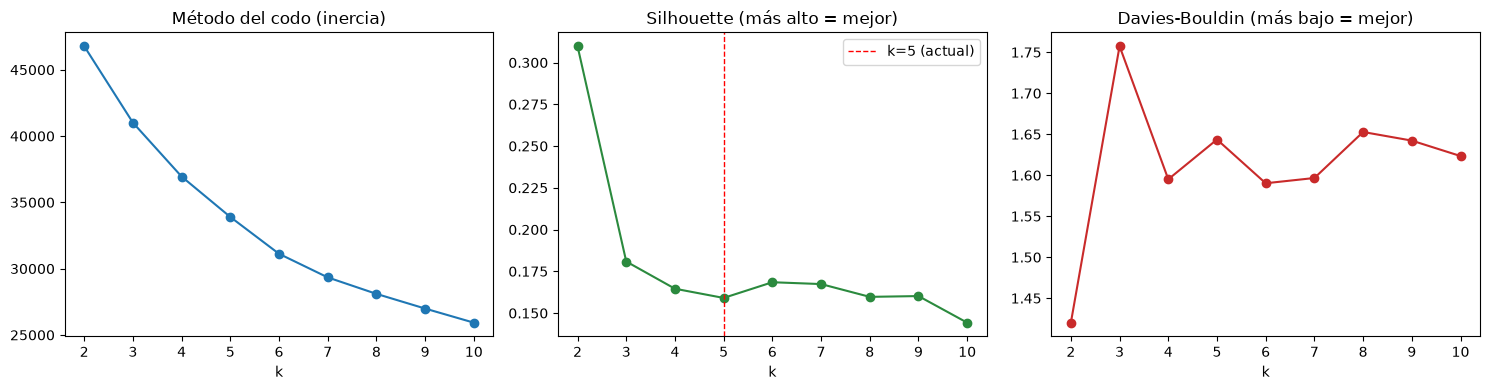

,k,inercia,silhouette,davies_bouldin
0,2,46780.420982,0.309804,1.420170
1,3,41010.945565,0.180870,1.757426
2,4,36946.015345,0.164580,1.595039
3,5,33897.784343,0.159069,1.643575
4,6,31120.749309,0.168469,1.590209
5,7,29342.084871,0.167371,1.596622
6,8,28099.438867,0.159715,1.652739
7,9,26990.884700,0.160182,1.642228
8,10,25927.573142,0.144259,1.623413


In [5]:
resultados_k = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_baseline)
    resultados_k.append({
        "k": k,
        "inercia": km.inertia_,
        "silhouette": silhouette_score(X_baseline, labels),
        "davies_bouldin": davies_bouldin_score(X_baseline, labels),
    })
resultados_k = pd.DataFrame(resultados_k)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(resultados_k["k"], resultados_k["inercia"], marker="o")
axes[0].set_title("Método del codo (inercia)")
axes[0].set_xlabel("k")

axes[1].plot(resultados_k["k"], resultados_k["silhouette"], marker="o", color="#2b8a3e")
axes[1].set_title("Silhouette (más alto = mejor)")
axes[1].set_xlabel("k")
axes[1].axvline(5, color="red", ls="--", lw=1, label="k=5 (actual)")
axes[1].legend()

axes[2].plot(resultados_k["k"], resultados_k["davies_bouldin"], marker="o", color="#c92a2a")
axes[2].set_title("Davies-Bouldin (más bajo = mejor)")
axes[2].set_xlabel("k")

plt.tight_layout()
plt.show()
resultados_k

## 4. ¿Escala global o por posición?

Las 3 variables ofensivas vienen escaladas por posición desde `03`. Armamos una versión alternativa en escala global (sin tocar el dataset real) y comparamos silhouette + qué tan concentrados por posición quedan los clusters.

In [6]:
RAW_OFENSIVAS = ["Performance_Gls", "Performance_Ast", "Standard_Sh"]

# Las crudas ya no existen en fbref_tm_features.parquet (03 las eliminó tras escalar
# por posición) -- se recuperan de fbref_tm_eda.parquet, mismo merge de la sección 1.
df_raw_ofensivas = pd.read_parquet("../data/processed/fbref_tm_eda.parquet")[
    ["player_id", "saison_id"] + RAW_OFENSIVAS
].drop_duplicates(subset=["player_id", "saison_id"], keep="first")

df = df.merge(df_raw_ofensivas, on=["player_id", "saison_id"], how="left", suffixes=("", "_cruda"))

rs_global = RobustScaler().fit_transform(df[RAW_OFENSIVAS])
for i, c in enumerate(RAW_OFENSIVAS):
    df[f"{c}_rs_global"] = rs_global[:, i]

RS_COLS_GLOBAL = [
    "Age_rs", "altura_m_rs", "Playing Time_Min_rs",
    "Performance_Gls_rs_global", "Performance_Ast_rs_global", "Standard_Sh_rs_global",
    "Performance_CrdY_rs", "Team Success_PPM_rs",
]

X_global = df[RS_COLS_GLOBAL].to_numpy()
kmeans_global = KMeans(n_clusters=5, random_state=RANDOM_STATE, n_init=10)
cluster_global = kmeans_global.fit_predict(X_global)

print(f"Silhouette -- baseline (ofensivas por posición): {sil_baseline:.3f}")
print(f"Silhouette -- ofensivas en escala global:         {silhouette_score(X_global, cluster_global):.3f}")

Silhouette -- baseline (ofensivas por posición): 0.159


Silhouette -- ofensivas en escala global:         0.177


In [7]:
df["cluster_global"] = cluster_global
print("Composición por posición de cada cluster (variables ofensivas en escala GLOBAL):")
pd.crosstab(df["cluster_global"], df["posicion_tm"], normalize="index").round(2).style.background_gradient(axis=1, cmap="Blues")

Composición por posición de cada cluster (variables ofensivas en escala GLOBAL):


posicion_tm,Attacking Midfield,Central Midfield,Centre-Back,Centre-Forward,Defensive Midfield,Goalkeeper,Left Midfield,Left Winger,Left-Back,Right Midfield,Right Winger,Right-Back,Second Striker
cluster_global,,,,,,,,,,,,,
0,0.030000,0.150000,0.280000,0.060000,0.120000,0.070000,0.000000,0.030000,0.090000,0.010000,0.030000,0.120000,0.000000
1,0.070000,0.120000,0.170000,0.150000,0.060000,0.100000,0.010000,0.080000,0.070000,0.010000,0.080000,0.080000,0.010000
2,0.140000,0.160000,0.020000,0.240000,0.050000,0.000000,0.010000,0.150000,0.040000,0.010000,0.130000,0.040000,0.020000
3,0.110000,0.030000,0.000000,0.570000,0.010000,0.000000,0.000000,0.120000,0.000000,0.000000,0.120000,0.000000,0.030000
4,0.060000,0.120000,0.220000,0.080000,0.090000,0.110000,0.000000,0.060000,0.080000,0.010000,0.060000,0.100000,0.010000


Esta es la prueba real: si acá los clusters quedan mucho más concentrados por posición que en el baseline, confirma que escalar por posición le sacaba al clustering justo la señal que necesitaba.

## 5. ¿Otro algoritmo le gana a KMeans?

Con el conjunto de variables que ganó en la sección anterior, comparamos KMeans contra GaussianMixture (clusters elípticos) y Agglomerative (jerárquico).

In [8]:
# Ajustar X_ELEGIDO según lo que muestre la sección 4 (por ahora, igual al baseline)
X_ELEGIDO = X_baseline

gmm = GaussianMixture(n_components=5, random_state=RANDOM_STATE, n_init=10)
cluster_gmm = gmm.fit_predict(X_ELEGIDO)

agglo = AgglomerativeClustering(n_clusters=5)
cluster_agglo = agglo.fit_predict(X_ELEGIDO)

comparacion_algoritmos = pd.DataFrame({
    "algoritmo": ["KMeans", "GaussianMixture", "Agglomerative"],
    "silhouette": [
        silhouette_score(X_ELEGIDO, cluster_baseline),
        silhouette_score(X_ELEGIDO, cluster_gmm),
        silhouette_score(X_ELEGIDO, cluster_agglo),
    ],
    "davies_bouldin": [
        davies_bouldin_score(X_ELEGIDO, cluster_baseline),
        davies_bouldin_score(X_ELEGIDO, cluster_gmm),
        davies_bouldin_score(X_ELEGIDO, cluster_agglo),
    ],
})
comparacion_algoritmos

,algoritmo,silhouette,davies_bouldin
0,KMeans,0.159069,1.643575
1,GaussianMixture,-0.003435,3.841428
2,Agglomerative,0.095487,2.016102


## 6. Visualización (PCA 2D)

Solo para mirar -- los clusters se calculan sobre las 8 dimensiones originales, esto es nada más una proyección para inspeccionar.

Varianza explicada por las 2 componentes: 56.5%


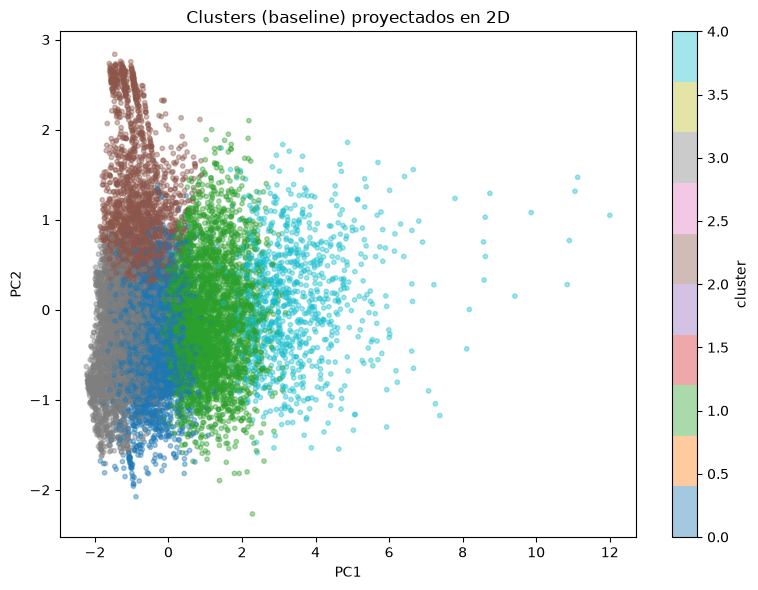

In [9]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
coords = pca.fit_transform(X_baseline)
print(f"Varianza explicada por las 2 componentes: {pca.explained_variance_ratio_.sum():.1%}")

fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(coords[:, 0], coords[:, 1], c=cluster_baseline, cmap="tab10", alpha=0.4, s=10)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("Clusters (baseline) proyectados en 2D")
plt.colorbar(scatter, label="cluster")
plt.tight_layout()
plt.show()

## 7. Conclusión

- **¿`k=5` es óptimo?** No exactamente (silhouette mejor en k=2), pero tampoco hay nada claramente mejor entre 3 y 9 -- lo dejamos en 5.
- **¿Escala global ayuda?** Sí, confirmado: por posición ningún cluster pasaba de 30% de concentración; en global aparece uno 57% delanteros centro -- ahí sí se nota un arquetipo real de "goleador".
- **¿Otro algoritmo gana?** No -- GaussianMixture sale degenerado y Agglomerative queda por debajo.
- **Aplicado a producción:** el script ahora calcula esas 3 variables ofensivas en escala global solo para el clustering, sin tocar las que usa el modelo de valor. Las etiquetas de arquetipo se reescribieron, pero el perfil salió casi igual al original -- tiene sentido, es básicamente volver a como se escalaba antes de que `03` empezara a relativizar por posición.